In [3]:
import importlib, os, duckdb, sys, json
import pandas as pd
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import io_utils.db_reader
importlib.reload(io_utils.db_reader)
from io_utils.db_reader import load_table_to_df, load_gis_to_df

pd.set_option('display.max_columns', None)
out_dir = r"C:\Users\mmh\OneDrive - Oak Ridge National Laboratory\nashville_microsim\Model\SUMO\xml"
map_dir = r'C:\Users\mmh\OneDrive - Oak Ridge National Laboratory\nashville_microsim\Geo Data'
data_dir = r"C:\Users\mmh\OneDrive - Oak Ridge National Laboratory\nashville_microsim\Model\GNRC ABM"
shp_dir = r'C:\Users\mmh\OneDrive - Oak Ridge National Laboratory\nashville_microsim\Model\SUMO\shp'

# person trip

In [15]:
start_hour = 0 # 6
end_hour = 12 # 7
person_out_name = f"trips_person_{start_hour}_{end_hour}"
person_trips_csv = os.path.join(out_dir, "demand", person_out_name+".csv")

In [16]:
person_trips = pd.read_csv(person_trips_csv)

person_trips['unique_id'] = person_trips['hhno'].astype(str) + '_' + person_trips['pno'].astype(str)
trip_chain = person_trips.groupby('unique_id')['id'].apply(list).to_dict()
reverse_trip_chain = {f"person_{t_id}": p_id for p_id, trips in trip_chain.items() for t_id in trips}

In [4]:
person_trips.head()
# travdist # network travel distance, miles (by sov)
# travtime # network travel time, min (by sov)

,id,tour_id,hhno,pno,day,tour,half,tseg,tsvid,opurp,dpurp,oadtyp,dadtyp,opcl,otaz,dpcl,dtaz,mode,pathtype,dorp,deptm,arrtm,endacttm,travtime,travcost,travdist,vot,trexpfac,to,from,vType
0,1102,11,1,1,1,1,1,1,0,0,7,1,4,2798,89,9579,866,car,1,1,27600.0,467,480,7.603512,0.608563,2.434252,45.444857,1,55446_rev,54410_rev,passenger
1,1101,11,1,1,1,1,1,2,0,7,1,4,2,9579,866,23271,2557,car,1,1,28800.0,490,1038,10.840000,1.272500,5.090000,45.444857,1,57078,55446_rev,passenger
2,3102,31,2,1,1,1,1,1,0,0,6,1,4,2798,89,14318,1374,car,1,1,16560.0,306,380,30.220000,5.325000,21.300000,60.021758,1,8608_rev,55333_rev,passenger
3,3101,31,2,1,1,1,1,2,0,6,1,4,4,14318,1374,11167,2439,car,1,1,22800.0,417,837,37.840000,3.342500,13.370000,34.475450,1,4198,8608_rev,passenger
4,11101,111,4,2,1,1,1,1,0,0,4,1,4,6465,89,15682,470,car,1,1,39600.0,703,724,43.110000,6.835000,27.340000,21.786580,1,19236_rev,54411,passenger


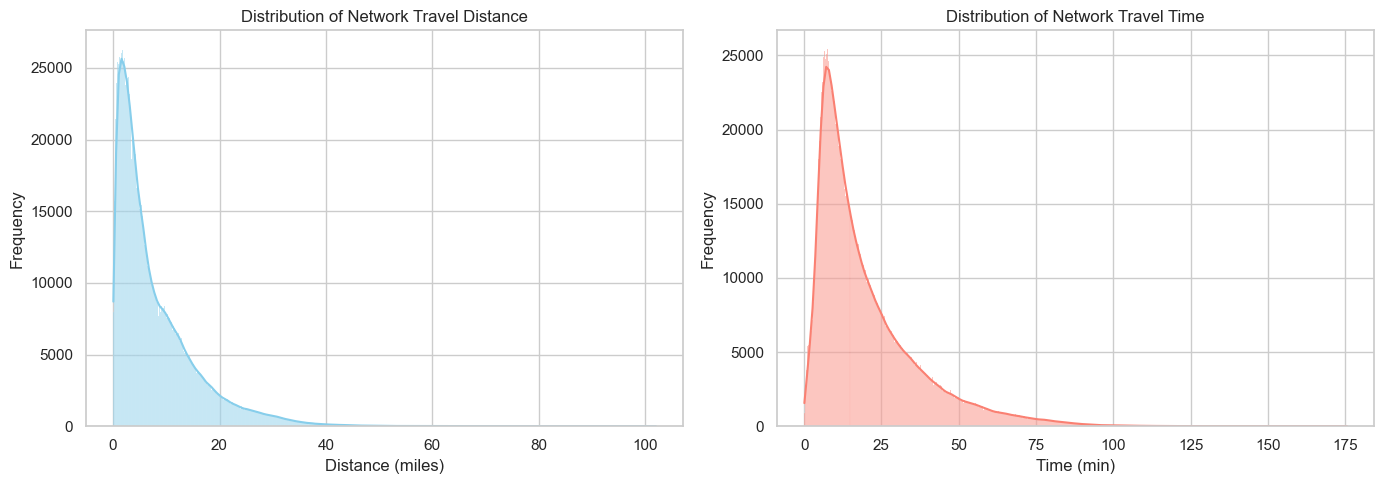

In [8]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Distribution of Travel Distance
sns.histplot(person_trips['travdist'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Network Travel Distance')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Frequency')

# Plot Distribution of Travel Time
sns.histplot(person_trips['travtime'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Network Travel Time')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# trips from SUMO

In [5]:
db_path = os.path.join("..", "sumo_output.db")
con = duckdb.connect(db_path)
job_to_analyze = "20260225"
trips_simulation = load_table_to_df("all_trips", con, job_id=job_to_analyze)
con.close()

📖 Loaded 148324 rows from 'all_trips'


In [6]:
trips_simulation.head()

,id,depart,departLane,departPos,departSpeed,departDelay,arrival,arrivalLane,arrivalPos,arrivalSpeed,duration,routeLength,waitingTime,waitingCount,stopTime,timeLoss,rerouteNo,devices,vType,speedFactor,vaporized,sim_job_id
0,person_1870062101,27900.0,98548_rev_0,5.1,53.753668,0.0,27903.0,98548_rev_0,56.72,52.747045,0.050000,0.032075,0.000000,0,0.0,0.000500,0,tripinfo_person_1870062101,passenger,1.19,,20260225
1,person_606839101,27900.0,83373_rev_0,5.1,25.836657,0.0,27909.0,83373_rev_0,95.50,24.740556,0.150000,0.056172,0.000000,0,0.0,0.008333,0,tripinfo_person_606839101,passenger,0.96,,20260225
2,person_158511102,27900.0,73278_rev_0,5.1,29.415761,0.0,27912.0,73278_rev_0,145.59,27.961750,0.200000,0.087296,0.000000,0,0.0,0.012000,0,tripinfo_person_158511102 stationfinder_person...,EV_car_std,0.98,,20260225
3,person_1496508201,27900.0,6487_rev_0,5.1,16.821789,0.0,27916.0,6488_rev_0,15.35,42.054472,0.266667,0.162302,0.000000,0,0.0,0.027167,0,tripinfo_person_1496508201,passenger,1.06,,20260225
4,person_790190251,27900.0,67523_rev_0,0.2,31.406638,0.0,27918.0,67573_rev_0,76.52,27.469623,0.300000,0.097686,0.016667,1,0.0,0.106667,0,tripinfo_person_790190251,passenger,1.05,,20260225


In [17]:
person_trips_sim = trips_simulation[trips_simulation['id'].str.startswith("person_")].copy()
person_trips_sim['person_id'] = person_trips_sim['id'].map(reverse_trip_chain)
person_trips_sim.head()

,id,depart,departLane,departPos,departSpeed,departDelay,arrival,arrivalLane,arrivalPos,arrivalSpeed,duration,routeLength,waitingTime,waitingCount,stopTime,timeLoss,rerouteNo,devices,vType,speedFactor,vaporized,sim_job_id,person_id
0,person_1870062101,27900.0,98548_rev_0,5.1,53.753668,0.0,27903.0,98548_rev_0,56.72,52.747045,0.050000,0.032075,0.000000,0,0.0,0.000500,0,tripinfo_person_1870062101,passenger,1.19,,20260225,777257_1
1,person_606839101,27900.0,83373_rev_0,5.1,25.836657,0.0,27909.0,83373_rev_0,95.50,24.740556,0.150000,0.056172,0.000000,0,0.0,0.008333,0,tripinfo_person_606839101,passenger,0.96,,20260225,238230_2
2,person_158511102,27900.0,73278_rev_0,5.1,29.415761,0.0,27912.0,73278_rev_0,145.59,27.961750,0.200000,0.087296,0.000000,0,0.0,0.012000,0,tripinfo_person_158511102 stationfinder_person...,EV_car_std,0.98,,20260225,60255_1
3,person_1496508201,27900.0,6487_rev_0,5.1,16.821789,0.0,27916.0,6488_rev_0,15.35,42.054472,0.266667,0.162302,0.000000,0,0.0,0.027167,0,tripinfo_person_1496508201,passenger,1.06,,20260225,604462_1
4,person_790190251,27900.0,67523_rev_0,0.2,31.406638,0.0,27918.0,67573_rev_0,76.52,27.469623,0.300000,0.097686,0.016667,1,0.0,0.106667,0,tripinfo_person_790190251,passenger,1.05,,20260225,303443_1


In [28]:
ev_trips = person_trips_sim[person_trips_sim['vType'].isin(['EV_car_std','EV_car_long'])].copy() 
ev_trips['stopTime'].describe()

count    8712.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: stopTime, dtype: float64

In [80]:
trips_simulation[trips_simulation.id == "person_1164855101"]

,id,depart,departLane,departPos,departSpeed,departDelay,arrival,arrivalLane,arrivalPos,arrivalSpeed,duration,routeLength,waitingTime,waitingCount,stopTime,timeLoss,rerouteNo,devices,vType,speedFactor,vaporized,sim_job_id,duration_min
148246,person_1164855101,30300.0,40427_0,5.1,29.169698,0.0,32396.0,91371_rev_0,398.16,53.820776,34.933333,21.929276,2.05,6,0.0,4.7125,0,tripinfo_person_1164855101,passenger,1.08,,20260225,34.933333


In [23]:
trips_simulation['depart'].min()/3600, trips_simulation['depart'].max()/3600

(np.float64(7.75), np.float64(8.990833333333333))

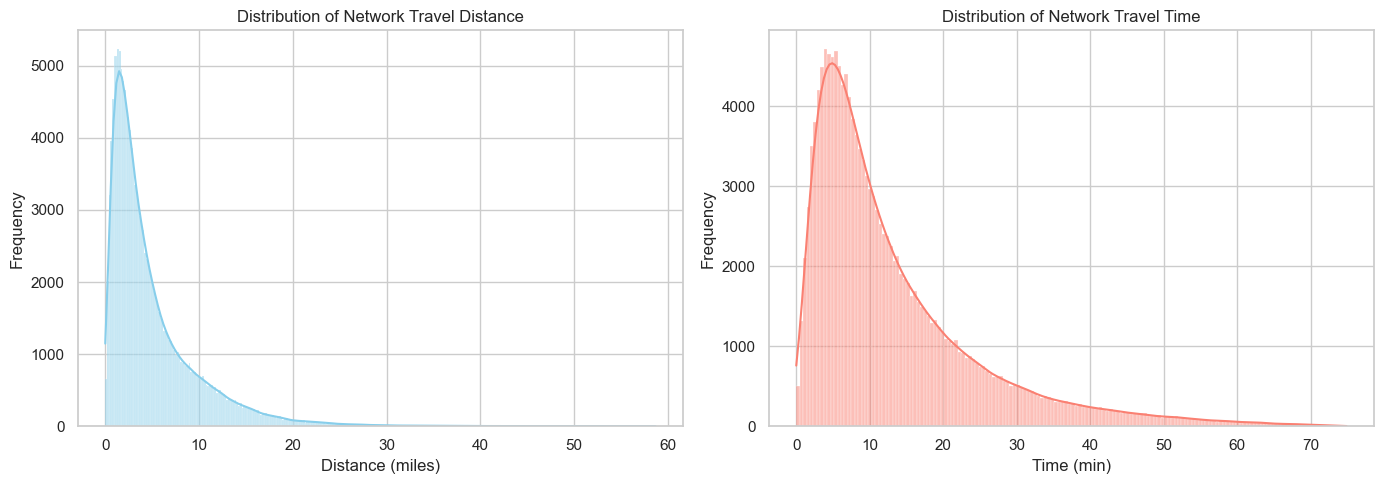

In [81]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Distribution of Travel Distance
sns.histplot(trips_simulation['routeLength'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Network Travel Distance')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Frequency')

# Plot Distribution of Travel Time
sns.histplot(trips_simulation['duration'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Network Travel Time')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Validate trip chain

In [ ]:
# find subset with the same person_id with multiple entries
multi_trip_users = person_trips_sim.groupby('person_id').filter(lambda x: len(x) > 1)
multi_trip_users = multi_trip_users.sort_values(by=['person_id', 'depart'])
multi_trip_users.head()

In [ ]:
# for each person_id regardless of ev: whether the arrival is higher than the next depart
print(f"Found {len(multi_trip_users)} trips.")
multi_trip_users['prev_arrival'] = multi_trip_users.groupby('person_id')['arrival'].shift(1)
multi_trip_users['has_overlap'] = multi_trip_users['depart'] < multi_trip_users['prev_arrival']
conflicts = multi_trip_users[multi_trip_users['has_overlap'] == True]
print(f"Found {len(conflicts)} trip overlaps.")

Found 35920 trips.
Found 1484 trip overlaps.


# Compare travel time

In [21]:
trips_simulation_person = trips_simulation[trips_simulation['id'].str.startswith("person_")]
trips_simulation_person['id'] = trips_simulation_person['id'].str.replace("person_", "").astype(int)
matched = pd.merge(trips_simulation_person[['id', 'routeLength', 'duration']],
                   person_trips[['id','travdist', 'travtime']], on='id', how='left')
matched.head()

,id,routeLength,duration,travdist,travtime
0,1870062101,0.032075,0.050000,0.433557,3.530390
1,606839101,0.056172,0.150000,0.344508,1.077004
2,158511102,0.087296,0.200000,0.506321,4.266022
3,1496508201,0.162302,0.266667,0.574286,4.119018
4,790190251,0.097686,0.300000,0.375379,2.186730


Text(0, 0.5, 'True Travel Distance (miles)')

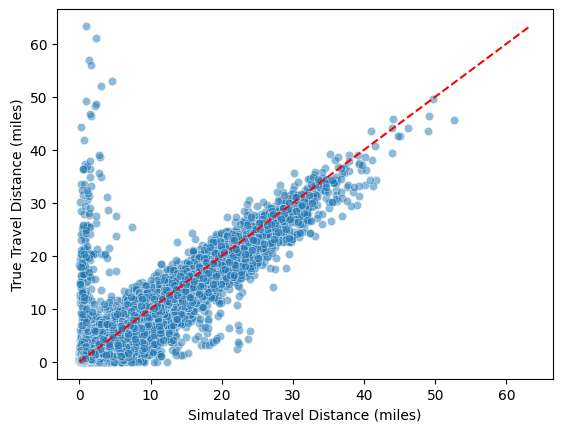

In [22]:
# 45-degree line between travdist and routeLength
sns.scatterplot(x=matched['routeLength'], y=matched['travdist'], alpha=0.5)
plt.plot([0, matched['travdist'].max()], [0, matched['travdist'].max()], 'r--')
plt.xlabel('Simulated Travel Distance (miles)')
plt.ylabel('True Travel Distance (miles)')

In [ ]:
db_gis_path = os.path.join(shp_dir, "sumo_data.duckdb")
links = load_gis_to_df(db_gis_path, "links_sumo_wcc")

print(links.crs)
links.head(3)

# distance between link centroids, 40427 and 91371_rev
link_a = links[links['ID'] == '40427'].geometry.iloc[0]
link_b = links[links['ID'] == '91371_rev'].geometry.iloc[0]

# 2. Get the centroids
centroid_a = link_a.centroid
centroid_b = link_b.centroid

# 3. Calculate distance in meters
distance_meters = centroid_a.distance(centroid_b)


# 4. Convert meters to miles
distance_miles = distance_meters * 0.000621371

distance_miles # # distance between link centroids, 40427 and 91371_rev
link_a = links[links['ID'] == '40427'].geometry.iloc[0]
link_b = links[links['ID'] == '91371_rev'].geometry.iloc[0]

# 2. Get the centroids
centroid_a = link_a.centroid
centroid_b = link_b.centroid

# 3. Calculate distance in meters
distance_meters = centroid_a.distance(centroid_b)


# 4. Convert meters to miles
distance_miles = distance_meters * 0.000621371

distance_miles # 21.974382211964187 miles

# read taz shapefile

In [28]:
taz = gpd.read_file(os.path.join(map_dir,'Zones','TAZ_2020_pop_emp_hh.shp'))
taz = taz.to_crs(epsg=3857)
taz.head()

,ID,AREA,TAZ_ID,ALAND20,AWATER20,HOUSING20,POP20,PREDICT,CBD,URBAN,SU,RURAL,AREA2,SHAPE_AREA,POP,EMP,HH,AREA05,POP05,EMP05,HH05,D_POP05,D_EMP05,D_HH05,ALLON,ALLOFF,MOE_DIST1,MOE_DIST2,geometry
0,1803,0.483181,1803,1086255.0,165275.0,0.0,0.0,SU,0.001842,0.183039,0.614367,2.007517e-01,0.483181,1.347033e+07,0,0,0,1.921289,546,519,235,284.184278,270.131210,122.313746,0,0,Columbia,MAURY,"POLYGON ((-9685652.636 4249499.134, -9685700.7..."
1,1802,0.788536,1802,2031556.0,10900.0,8.0,35.0,SU,0.004631,0.389609,0.605159,6.012407e-04,0.788536,2.198316e+07,17,0,8,3.057449,3143,2610,1358,1027.981196,853.652854,444.161140,0,0,Columbia,MAURY,"POLYGON ((-9685906.779 4250196.803, -9685906.2..."
2,1820,0.277822,1820,719612.0,0.0,133.0,271.0,URBAN,0.008988,0.571889,0.419123,4.898000e-08,0.277822,7.745235e+06,217,1573,119,2.850955,3531,6801,1692,1238.532194,2385.516129,593.485265,0,0,Columbia,MAURY,"POLYGON ((-9686716.294 4248388.489, -9686717.2..."
3,1,32.798874,1,3825534.0,81142911.0,19.0,69.0,SU,0.004791,0.391012,0.603950,2.468976e-04,32.798874,9.143818e+08,43,9,23,144.313870,130649,158401,61212,905.311456,1097.614523,424.158813,0,0,Middle Core I-65,WILSON,"MULTIPOLYGON (((-9686611.877 4249816.873, -968..."
4,2809,0.345440,2809,861140.0,33615.0,425.0,948.0,URBAN,0.009277,0.581833,0.408890,2.976000e-08,0.345440,9.630328e+06,963,48,391,2.445954,3070,6022,1376,1255.133917,2462.024902,562.561651,0,0,Columbia,MAURY,"POLYGON ((-9686539.964 4249965.885, -9686548.5..."


In [29]:
len(set(taz['ID']))

3007

In [33]:
maz = gpd.read_file(os.path.join(map_dir,'Zones','MAZ_2023_SE 2025-03-03.zip'))
maz.head(2)

,ID,AREA,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,XCOORD,YCOORD,XCOORD_P,YCOORD_P,HHSIZE,HH_P,STUGRD_P,STUHGH_P,STUUNI_P,EMPEDU_P,EMPFOO_P,EMPGOV_P,EMPIND_P,EMPMED_P,EMPOFC_P,EMPRET_P,EMPSVC_P,EMPOTH_P,EMPTOT_P,geometry
0,5014,0.209422,47,119,010900,2021,471190109002021,-87.330221,35.655780,1573332,484063,10.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((1572732.469 482203.738, 1572825.037 ..."
1,5013,0.065362,47,119,010900,2020,471190109002020,-87.332091,35.644361,1572720,479915,8.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((1572732.469 482203.738, 1572738.435 ..."


In [34]:
len(set(maz['ID']))

27925